# Task 1: Data Cleaning and Formatting

In [1]:
## Step 0: Import dataset and basic inspection
import pandas as pd

df = pd.read_csv("goldman_sachs.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [2]:
## Step 1: Remove/treat special characters or non-numeric entries from financial fields
# Convert financial columns to string for inspection
df['TransactionAmount'] = df['TransactionAmount'].astype(str)
df['AccountBalance'] = df['AccountBalance'].astype(str)

# Look at a few values
df['TransactionAmount'].head()
df['AccountBalance'].head()


0     74008.4331
1     22715.8359
2     42706.0921
3    114176.5687
4    17863.02644
Name: AccountBalance, dtype: object

No special characters or non-numeric entries were found in TransactionAmount and AccountBalance, so no replacement was required.


In [3]:
## Step 2: Convert currency amounts into numerical format
# Convert to float (numeric)
df['TransactionAmount'] = df['TransactionAmount'].astype(float)
df['AccountBalance'] = df['AccountBalance'].astype(float)

# Verify
df[['TransactionAmount', 'AccountBalance']].dtypes
df[['TransactionAmount', 'AccountBalance']].describe()


,TransactionAmount,AccountBalance
count,800.000000,800.000000
mean,51575.671765,72345.657910
std,29055.838886,34070.038539
min,-30721.247890,-37293.600250
25%,31692.004800,49157.502723
50%,50249.069385,72789.370195
75%,71913.394570,95352.455698
max,130726.914100,175247.539500


### Step 2: Convert currency amounts into numerical format

In this step, the `TransactionAmount` and `AccountBalance` columns were converted to `float` data type using `astype(float)`. The `.describe()` summary confirms that both fields are now numeric and ready for further analysis.


In [4]:
## Step 3: Validate and format date columns
# Check original format of the date column
df['TransactionDate'].head()

# Convert from DD-MM-YYYY to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y')

# Create a formatted date string (YYYY-MM-DD) for reporting/Excel
df['TransactionDateFormatted'] = df['TransactionDate'].dt.strftime('%Y-%m-%d')

# Validate date range
df['TransactionDate'].min(), df['TransactionDate'].max()


(Timestamp('2023-01-02 00:00:00'), Timestamp('2024-06-22 00:00:00'))

 Validate and format date columns

In this step, the `TransactionDate` column was checked and converted from the original `DD-MM-YYYY` string format to a proper `datetime` type using `pd.to_datetime` with the format `%d-%m-%Y`.  
A new column, `TransactionDateFormatted`, was created in `YYYY-MM-DD` format for easier reporting and export to Excel.  
The minimum and maximum dates (2023-01-02 to 2024-06-22) confirm that the date values are valid and fall within a reasonable range.


## Step 4: Ensure account types and transaction categories are standardized


In [5]:
# Standardize AccountType
df['AccountType'].unique()

account_type_map = {
    'Savings': 'Savings Account',
    'Current': 'Current Account',
    'Loan': 'Loan Account',
    'Credit': 'Credit Card Account'
}
df['AccountType'] = df['AccountType'].map(account_type_map)
df['AccountType'].value_counts()

# Standardize TransactionType
df['TransactionType'].unique()

transaction_type_map = {
    'Deposit': 'Credit Transaction',
    'Withdrawal': 'Debit Transaction',
    'Transfer': 'Transfer Transaction',
    'Payment': 'Payment Transaction'
}
df['TransactionType'] = df['TransactionType'].map(transaction_type_map)
df['TransactionType'].value_counts()


TransactionType
Debit Transaction       207
Payment Transaction     200
Credit Transaction      199
Transfer Transaction    194
Name: count, dtype: int64

## Step 4: Ensure account types and transaction categories are standardized

In this step, the raw `AccountType` values (`Savings`, `Current`, `Loan`, `Credit`) were mapped to consistent labels: **Savings Account**, **Current Account**, **Loan Account**, and **Credit Card Account** using a dictionary and the `map()` function.  

Similarly, the `TransactionType` column was standardized into four clear categories: **Credit Transaction** (for deposits), **Debit Transaction** (for withdrawals), **Transfer Transaction**, and **Payment Transaction**.  
This standardization ensures that all account and transaction categories are consistent for analysis and reporting.


# Task 2: Descriptive Transactional Analysis


In [6]:
import numpy as np


In [7]:
# Year and Month for grouping
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

# SignedAmount: + for credits, - for debits
df['SignedAmount'] = df['TransactionAmount']
df.loc[df['TransactionType'] == 'Debit Transaction', 'SignedAmount'] *= -1

df[['TransactionDate','Year','Month','TransactionType','TransactionAmount','SignedAmount']].head()


,TransactionDate,Year,Month,TransactionType,TransactionAmount,SignedAmount
0,2023-10-21,2023,10,Debit Transaction,87480.05448,-87480.05448
1,2023-06-20,2023,6,Debit Transaction,20315.74505,-20315.74505
2,2023-01-02,2023,1,Credit Transaction,10484.57165,10484.57165
3,2023-07-25,2023,7,Debit Transaction,45122.27373,-45122.27373
4,2023-07-25,2023,7,Debit Transaction,42360.79878,-42360.79878


In [8]:
# Amount only when transaction is credit
df['CreditAmount'] = np.where(
    df['TransactionType'] == 'Credit Transaction',
    df['TransactionAmount'],
    0
)

# Amount only when transaction is debit
df['DebitAmount'] = np.where(
    df['TransactionType'] == 'Debit Transaction',
    df['TransactionAmount'],
    0
)

# Monthly summary
monthly_summary = (
    df.groupby(['Year', 'Month'])
      .agg(TotalCredits=('CreditAmount', 'sum'),
           TotalDebits=('DebitAmount', 'sum'),
           NetVolume=('SignedAmount', 'sum'),
           TransactionCount=('TransactionID', 'count'))
      .reset_index()
)

monthly_summary.head()

# Yearly summary
yearly_summary = (
    df.groupby('Year')
      .agg(TotalCredits=('CreditAmount', 'sum'),
           TotalDebits=('DebitAmount', 'sum'),
           NetVolume=('SignedAmount', 'sum'),
           TransactionCount=('TransactionID', 'count'))
      .reset_index()
)

yearly_summary


,Year,TotalCredits,TotalDebits,NetVolume,TransactionCount
0,2023,7.251369e+06,8.013988e+06,1.232221e+07,542
1,2024,3.229767e+06,2.827657e+06,7.255040e+06,258


### Step 2.3: Trend of total credits vs debits over time


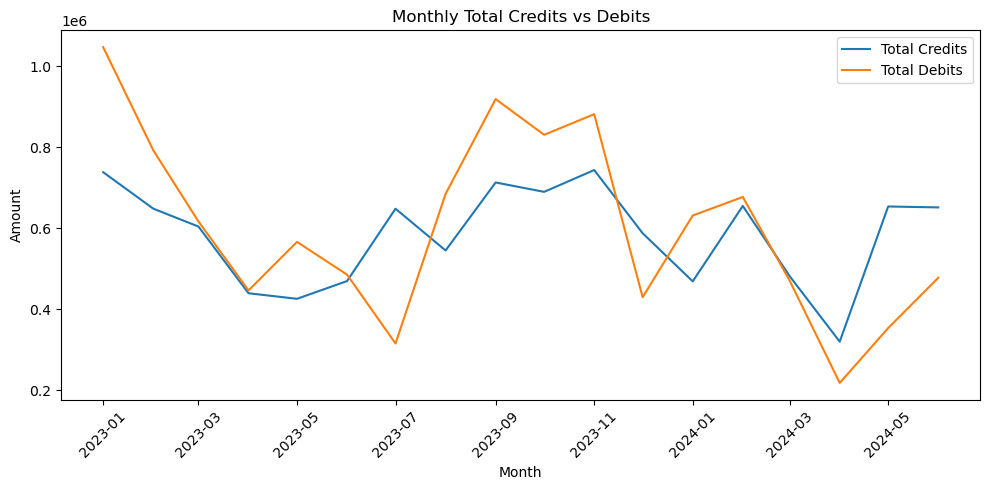

In [9]:
import matplotlib.pyplot as plt

# Create a Period column for plotting (first day of each month)
monthly_summary['Period'] = pd.to_datetime(
    monthly_summary['Year'].astype(str) + '-' +
    monthly_summary['Month'].astype(str).str.zfill(2) + '-01'
)

plt.figure(figsize=(10,5))
plt.plot(monthly_summary['Period'], monthly_summary['TotalCredits'], label='Total Credits')
plt.plot(monthly_summary['Period'], monthly_summary['TotalDebits'], label='Total Debits')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Monthly Total Credits vs Debits')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Step 2.4: Top and bottom performing accounts based on net inflow


In [10]:
account_inflow = (
    df.groupby('AccountID')
      .agg(NetInflow=('SignedAmount', 'sum'),
           TotalCredits=('CreditAmount', 'sum'),
           TotalDebits=('DebitAmount', 'sum'),
           TransactionCount=('TransactionID', 'count'))
      .reset_index()
)

# Top 10 accounts (highest net inflow)
top_accounts = account_inflow.sort_values('NetInflow', ascending=False).head(10)

# Bottom 10 accounts (lowest net inflow)
bottom_accounts = account_inflow.sort_values('NetInflow', ascending=True).head(10)

top_accounts
bottom_accounts


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount
106,ACC52650,-202439.832090,0.00000,202439.83209,4
15,ACC17688,-149378.941520,0.00000,149378.94152,2
118,ACC60432,-123603.662900,39623.16730,293280.75639,8
113,ACC57597,-123390.476000,0.00000,108937.94791,3
160,ACC82381,-113000.932624,81377.64979,198614.66208,5
130,ACC67701,-111911.298630,9748.42634,192663.09700,5
35,ACC25132,-105617.817330,0.00000,174543.17755,5
183,ACC94242,-104353.528680,0.00000,156855.68433,4
128,ACC66086,-100668.633010,86843.34882,217994.46370,4
177,ACC91220,-100228.932700,0.00000,100228.93270,1


### Step 2.5: Dormant or inactive accounts (gap of two months or more)


In [11]:
# Sort by AccountID and date
df = df.sort_values(['AccountID', 'TransactionDate'])

# Previous transaction date for each account
df['PrevDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)

# Gap in days between current and previous transaction
df['GapDays'] = (df['TransactionDate'] - df['PrevDate']).dt.days

# Flag gaps >= 60 days (approx 2 months)
df['IsDormantGap'] = np.where(df['GapDays'] >= 60, 1, 0)

# Account-level dormant flag: 1 if any big gap
account_dormant_flag = (
    df.groupby('AccountID')['IsDormantGap']
      .max()
      .reset_index()
      .rename(columns={'IsDormantGap': 'IsDormantAccount'})
)

account_dormant_flag['IsDormantAccount'].value_counts()

# List of dormant accounts
dormant_accounts = account_dormant_flag[account_dormant_flag['IsDormantAccount'] == 1]
dormant_accounts.head()


,AccountID,IsDormantAccount
0,ACC10117,1
1,ACC10996,1
2,ACC11062,1
3,ACC11188,1
5,ACC11837,1


In [12]:
print(account_dormant_flag)


    AccountID  IsDormantAccount
0    ACC10117                 1
1    ACC10996                 1
2    ACC11062                 1
3    ACC11188                 1
4    ACC11285                 0
..        ...               ...
189  ACC97225                 1
190  ACC97411                 1
191  ACC99117                 1
192  ACC99409                 1
193  ACC99549                 1

[194 rows x 2 columns]


# Task 3: Customer Profile Building

## ● Group accounts by activity levels: High, Medium, Low based on transaction frequency on
## your analysis and rubrics. Do not forget to mention the rubric in the headings.


In [13]:
## Calculate transaction frequency per AccountID
txn_freq = (
    df.groupby("AccountID")["TransactionID"]
      .count()
      .reset_index()
)

txn_freq.rename(columns={"TransactionID": "TransactionCount"}, inplace=True)
txn_freq.head()



,AccountID,TransactionCount
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,5
4,ACC11285,3


This table now has one row per account with its transaction count.

In [14]:
##Step 3: Define the activity level rubric
def activity_bucket(n):
    if n >= 10:
        return "High Activity (≥10 txns)"
    elif n >= 5:
        return "Medium Activity (5–9 txns)"
    else:
        return "Low Activity (1–4 txns)"


In [15]:
# Step 4: Calculate transaction count per account
txn_freq = (
    df.groupby("AccountID")["TransactionID"]
      .count()
      .reset_index()
)
txn_freq.rename(columns={"TransactionID": "TransactionCount"}, inplace=True)

# Step 5: Apply the activity rubric
txn_freq["ActivityLevel"] = txn_freq["TransactionCount"].apply(activity_bucket)

# Step 6: Display results
txn_freq.head()                 # first few rows
txn_freq["ActivityLevel"].value_counts()   # counts in each band


ActivityLevel
Low Activity (1–4 txns)       121
Medium Activity (5–9 txns)     70
High Activity (≥10 txns)        3
Name: count, dtype: int64

## Segment customers by average balance and transaction volume.

In [16]:
# --- Step A: base account_inflow table (include AvgBalance) ---

account_inflow = df.groupby('AccountID').agg(
    NetInflow=('SignedAmount', 'sum'),
    TotalCredits=('CreditAmount', 'sum'),
    TotalDebits=('DebitAmount', 'sum'),
    TransactionCount=('TransactionID', 'count'),
    AvgBalance=('AccountBalance', 'mean')   # <-- important
).reset_index()



In [17]:
# --- Step B: activity level from TransactionCount ---

q_low = account_inflow['TransactionCount'].quantile(0.33)
q_high = account_inflow['TransactionCount'].quantile(0.66)

def activity_level(n):
    if n <= q_low:
        return 'Low Activity'
    elif n <= q_high:
        return 'Medium Activity'
    else:
        return 'High Activity'

account_inflow['ActivityLevel'] = account_inflow['TransactionCount'].apply(activity_level)


In [18]:
# --- Step C: balance band from AvgBalance ---

b_low = account_inflow['AvgBalance'].quantile(0.33)
b_high = account_inflow['AvgBalance'].quantile(0.66)

def balance_band(b):
    if b <= b_low:
        return 'Low Balance'
    elif b <= b_high:
        return 'Medium Balance'
    else:
        return 'High Balance'

account_inflow['BalanceBand'] = account_inflow['AvgBalance'].apply(balance_band)

account_inflow.head()


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance,ActivityLevel,BalanceBand
0,ACC10117,199480.967430,142170.20378,0.00000,4,70107.007957,Medium Activity,Medium Balance
1,ACC10996,120819.856210,62580.86356,64959.84737,5,43568.008084,Medium Activity,Low Balance
2,ACC11062,4014.264900,0.00000,0.00000,2,38137.132610,Low Activity,Low Balance
3,ACC11188,42532.553850,45748.34156,107522.02487,5,69652.151044,Medium Activity,Medium Balance
4,ACC11285,96729.609841,0.00000,0.00000,3,97401.348560,Low Activity,High Balance


## Create profiles for:
## ○ High-net inflow accounts
## ○ High-frequency low-balance accounts
## ○ Accounts with negative or near-zero balances

In [19]:
# High-net inflow = top 10 by NetInflow (i can change 10 to any number)
high_net_inflow_accounts = (
    account_inflow
    .sort_values('NetInflow', ascending=False)
    .head(10)
)

high_net_inflow_accounts


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance,ActivityLevel,BalanceBand
60,ACC33287,591591.095890,390354.426410,0.000000,8,59331.981186,High Activity,Low Balance
114,ACC57700,454243.336426,108837.513680,5402.294994,8,60537.126840,High Activity,Low Balance
8,ACC13357,432527.808260,51877.366170,0.000000,6,69179.806513,High Activity,Medium Balance
88,ACC46655,392604.303385,211669.279347,167716.549660,14,80109.059980,High Activity,High Balance
182,ACC94203,385750.785400,221569.909330,0.000000,7,79447.325560,High Activity,Medium Balance
120,ACC61926,353231.203320,101339.090640,0.000000,6,53209.096892,High Activity,Low Balance
92,ACC48501,346856.339600,346856.339600,0.000000,5,64565.232000,Medium Activity,Medium Balance
185,ACC95164,340602.161780,0.000000,0.000000,5,94546.840784,Medium Activity,High Balance
107,ACC53466,329241.906200,18181.673810,82857.626300,9,87092.865052,High Activity,High Balance
49,ACC29396,313039.270050,39888.001430,84840.372750,8,80302.140096,High Activity,High Balance


In [20]:
# Define thresholds (you can adjust)
txn_high = account_inflow['TransactionCount'].quantile(0.75)  # top 25% by activity
bal_low  = account_inflow['AvgBalance'].quantile(0.25)         # bottom 25% by balance

high_freq_low_bal = account_inflow[
    (account_inflow['TransactionCount'] >= txn_high) &
    (account_inflow['AvgBalance'] <= bal_low)
]

high_freq_low_bal.head()


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance,ActivityLevel,BalanceBand
1,ACC10996,120819.856210,62580.86356,64959.84737,5,43568.008084,Medium Activity,Low Balance
31,ACC24070,165574.238330,57864.13275,46374.69896,5,55694.967801,Medium Activity,Low Balance
40,ACC26973,289026.317264,57426.71190,0.00000,5,58738.210687,Medium Activity,Low Balance
42,ACC28292,68495.248192,48346.51243,146360.99215,10,51228.003570,High Activity,Low Balance
55,ACC31539,38430.485800,25819.70053,182166.94240,6,45185.938342,High Activity,Low Balance


In [21]:
# You can tune the near-zero threshold, e.g. |AvgBalance| <= 1000
near_zero_threshold = 1000

neg_or_near_zero_bal = account_inflow[
    (account_inflow['AvgBalance'] <= 0) |
    (account_inflow['AvgBalance'].abs() <= near_zero_threshold)
]

neg_or_near_zero_bal.head()


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance,ActivityLevel,BalanceBand
20,ACC19178,64100.78213,64100.78213,0.0,1,-1541.176812,Low Activity,Low Balance


In [22]:
# Basic checks
print(df.shape)
print(df.columns)

df[['AccountID','TransactionType','TransactionAmount','AccountBalance','SignedAmount','TransactionDate']].head()


(800, 24)
Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'TransactionDateFormatted', 'Year',
       'Month', 'SignedAmount', 'CreditAmount', 'DebitAmount', 'PrevDate',
       'GapDays', 'IsDormantGap'],
      dtype='object')


,AccountID,TransactionType,TransactionAmount,AccountBalance,SignedAmount,TransactionDate
468,ACC10117,Transfer Transaction,57310.76365,79464.39475,57310.76365,2023-01-30
25,ACC10117,Credit Transaction,67555.28072,89667.83479,67555.28072,2023-02-21
87,ACC10117,Credit Transaction,63248.56067,31961.53479,63248.56067,2023-06-18
742,ACC10117,Credit Transaction,11366.36239,79334.26750,11366.36239,2024-03-14
384,ACC10996,Debit Transaction,11989.50230,45731.50391,-11989.50230,2023-05-08


# Task 4: Financial Risk Identification

## Track accounts with frequent large withdrawals or overdrafts.


In [23]:
# Step 1: Flag large withdrawals at transaction level
large_withdrawal_threshold = 75000  # you can tune this

df['IsLargeWithdrawal'] = 0
mask_large_wd = (df['TransactionType'] == 'Debit Transaction') & \
                (df['TransactionAmount'].abs() >= large_withdrawal_threshold)
df.loc[mask_large_wd, 'IsLargeWithdrawal'] = 1

# Quick check
df.loc[df['IsLargeWithdrawal'] == 1,
       ['AccountID','TransactionDate','TransactionType','TransactionAmount']].head()


,AccountID,TransactionDate,TransactionType,TransactionAmount
0,ACC12334,2023-10-21,Debit Transaction,87480.05448
708,ACC15228,2024-02-06,Debit Transaction,79529.05133
459,ACC15359,2023-05-21,Debit Transaction,82926.69313
122,ACC16241,2023-02-17,Debit Transaction,88560.46331
477,ACC16241,2023-09-13,Debit Transaction,107454.87020


In [24]:
# Step 2: Flag overdraft rows
overdraft_threshold = 0  # anything below 0 treated as overdraft

df['IsOverdraft'] = (df['AccountBalance'] < overdraft_threshold).astype(int)

# Quick check
df.loc[df['IsOverdraft'] == 1,
       ['AccountID','TransactionDate','AccountBalance']].head()


,AccountID,TransactionDate,AccountBalance
122,ACC16241,2023-02-17,-19222.713000
618,ACC19178,2023-10-04,-1541.176812
607,ACC23736,2024-05-02,-9894.658427
174,ACC26973,2024-02-09,-8762.711283
400,ACC28154,2023-11-17,-97.392834


In [25]:
# Step 3A: aggregate per account – counts and rates
risk_flags = (
    df.groupby('AccountID')
      .agg(
          TotalTransactions = ('TransactionID', 'count'),
          LargeWithdrawals  = ('IsLargeWithdrawal', 'sum'),
          OverdraftDays     = ('IsOverdraft', 'sum')
      )
      .reset_index()
)

# Avoid division by zero
risk_flags['LargeWithdrawalRate'] = risk_flags['LargeWithdrawals'] / risk_flags['TotalTransactions']
risk_flags['OverdraftRate']       = risk_flags['OverdraftDays']    / risk_flags['TotalTransactions']

risk_flags.head()


,AccountID,TotalTransactions,LargeWithdrawals,OverdraftDays,LargeWithdrawalRate,OverdraftRate
0,ACC10117,4,0,0,0.0,0.0
1,ACC10996,5,0,0,0.0,0.0
2,ACC11062,2,0,0,0.0,0.0
3,ACC11188,5,0,0,0.0,0.0
4,ACC11285,3,0,0,0.0,0.0


In [26]:
# Step 3B: apply “frequent” thresholds
freq_large_wd_min_count = 3
freq_large_wd_min_rate  = 0.20
freq_overdraft_min_rate = 0.10

risk_flags['IsFreqLargeWithdrawal'] = (
    (risk_flags['LargeWithdrawals'] >= freq_large_wd_min_count) |
    (risk_flags['LargeWithdrawalRate'] >= freq_large_wd_min_rate)
).astype(int)

risk_flags['IsFreqOverdraft'] = (
    risk_flags['OverdraftRate'] >= freq_overdraft_min_rate
).astype(int)

# Accounts with frequent large withdrawals or overdrafts
frequent_risk_accounts = risk_flags[
    (risk_flags['IsFreqLargeWithdrawal'] == 1) |
    (risk_flags['IsFreqOverdraft'] == 1)
].copy()

frequent_risk_accounts.head()


,AccountID,TotalTransactions,LargeWithdrawals,OverdraftDays,LargeWithdrawalRate,OverdraftRate,IsFreqLargeWithdrawal,IsFreqOverdraft
9,ACC15228,5,1,0,0.200000,0.0,1,0
10,ACC15359,3,1,0,0.333333,0.0,1,0
13,ACC16241,10,2,1,0.200000,0.1,1,1
15,ACC17688,2,1,0,0.500000,0.0,1,0
20,ACC19178,1,0,1,0.000000,1.0,0,1


## ● Calculate balance volatility using standard deviation or coefficient of variation.


In [27]:
# Step 2.1: account-level balance series
# df already has: AccountID, AccountBalance, TransactionDate
# (and is cleaned + numeric from earlier tasks)

# Standard deviation of daily balance for each account
bal_volatility = (
    df.groupby('AccountID')
      .agg(
          BalStd = ('AccountBalance', 'std'),      # standard deviation
          BalMean = ('AccountBalance', 'mean')     # mean for CV
      )
      .reset_index()
)

# Step 2.2: Coefficient of variation (CV = std / mean)
# Handle zero / negative means safely
import numpy as np

bal_volatility['BalCV'] = np.where(
    bal_volatility['BalMean'] != 0,
    bal_volatility['BalStd'] / bal_volatility['BalMean'],
    np.nan
)

bal_volatility.head()


,AccountID,BalStd,BalMean,BalCV
0,ACC10117,25886.972758,70107.007957,0.369249
1,ACC10996,9434.002316,43568.008084,0.216535
2,ACC11062,3208.737888,38137.132610,0.084137
3,ACC11188,35494.660810,69652.151044,0.509599
4,ACC11285,55922.732441,97401.348560,0.574147


In [28]:
# Recreate accountinflow BEFORE using it in the merge
df['CreditAmount'] = np.where(df['TransactionType'] == 'Credit Transaction',
                              df['TransactionAmount'], 0)
df['DebitAmount'] = np.where(df['TransactionType'] == 'Debit Transaction',
                             df['TransactionAmount'], 0)

accountinflow = (
    df.groupby('AccountID')
      .agg(
          NetInflow        = ('SignedAmount', 'sum'),
          TotalCredits     = ('CreditAmount', 'sum'),
          TotalDebits      = ('DebitAmount', 'sum'),
          TransactionCount = ('TransactionID', 'count'),
          AvgBalance       = ('AccountBalance', 'mean')
      )
      .reset_index()
)


In [29]:
# Combine with accountinflow to keep all the existing metrics
account_vol_profile = (
    accountinflow        # from Task 3, already computed
    .merge(bal_volatility, on='AccountID', how='left')
)

account_vol_profile.head()


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance,BalStd,BalMean,BalCV
0,ACC10117,199480.967430,142170.20378,0.00000,4,70107.007957,25886.972758,70107.007957,0.369249
1,ACC10996,120819.856210,62580.86356,64959.84737,5,43568.008084,9434.002316,43568.008084,0.216535
2,ACC11062,4014.264900,0.00000,0.00000,2,38137.132610,3208.737888,38137.132610,0.084137
3,ACC11188,42532.553850,45748.34156,107522.02487,5,69652.151044,35494.660810,69652.151044,0.509599
4,ACC11285,96729.609841,0.00000,0.00000,3,97401.348560,55922.732441,97401.348560,0.574147


## ● Use IQR or z-score methods to detect anomalies.

In [30]:
# Step X: Anomaly detection using IQR (NetInflow and AvgBalance)

def iqr_flags(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

# 1) NetInflow anomalies
ni_lower, ni_upper = iqr_flags(accountinflow["NetInflow"])
accountinflow["IsNetInflowAnomaly"] = (
    (accountinflow["NetInflow"] < ni_lower) | 
    (accountinflow["NetInflow"] > ni_upper)
).astype(int)

# 2) AvgBalance anomalies
ab_lower, ab_upper = iqr_flags(accountinflow["AvgBalance"])
accountinflow["IsAvgBalanceAnomaly"] = (
    (accountinflow["AvgBalance"] < ab_lower) | 
    (accountinflow["AvgBalance"] > ab_upper)
).astype(int)

# 3) Combined anomaly flag: 1 if anomalous on either metric
accountinflow["IsAnyAnomaly"] = (
    (accountinflow["IsNetInflowAnomaly"] == 1) |
    (accountinflow["IsAvgBalanceAnomaly"] == 1)
).astype(int)

# Quick check: how many anomalies?
accountinflow["IsAnyAnomaly"].value_counts()
accountinflow[accountinflow["IsAnyAnomaly"] == 1].head()


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance,IsNetInflowAnomaly,IsAvgBalanceAnomaly,IsAnyAnomaly
8,ACC13357,432527.808260,51877.366170,0.000000,6,69179.806513,1,0,1
20,ACC19178,64100.782130,64100.782130,0.000000,1,-1541.176812,0,1,1
60,ACC33287,591591.095890,390354.426410,0.000000,8,59331.981186,1,0,1
88,ACC46655,392604.303385,211669.279347,167716.549660,14,80109.059980,1,0,1
114,ACC57700,454243.336426,108837.513680,5402.294994,8,60537.126840,1,0,1


## ● Highlight customers with irregular or suspicious transaction behavior.


# Task 5: Visual Exploratory Data Analysis (EDA)




In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


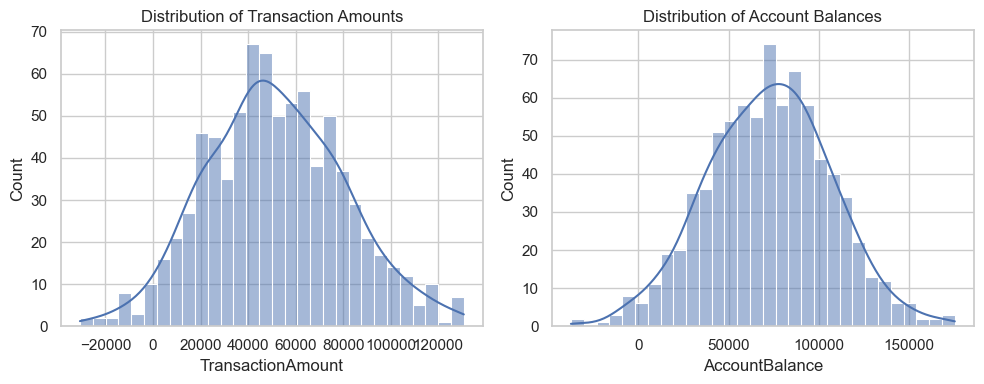

In [32]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["TransactionAmount"], bins=30, kde=True)
plt.title("Distribution of Transaction Amounts")

plt.subplot(1,2,2)
sns.histplot(df["AccountBalance"], bins=30, kde=True)
plt.title("Distribution of Account Balances")

plt.tight_layout()
plt.show()


## Monthly credits vs debits over time

In [33]:
# Amount only when transaction is credit
df["CreditAmount"] = np.where(df["TransactionType"] == "Credit Transaction",
                              df["TransactionAmount"], 0)

# Amount only when transaction is debit
df["DebitAmount"] = np.where(df["TransactionType"] == "Debit Transaction",
                             df["TransactionAmount"], 0)

# Monthly summary
monthlysummary = (
    df.groupby(["Year", "Month"])
      .agg(
          TotalCredits=("CreditAmount", "sum"),
          TotalDebits=("DebitAmount", "sum"),
          NetVolume=("SignedAmount", "sum"),
          TransactionCount=("TransactionID", "count")
      )
      .reset_index()
)

# Yearly summary (optional)
yearlysummary = (
    df.groupby("Year")
      .agg(
          TotalCredits=("CreditAmount", "sum"),
          TotalDebits=("DebitAmount", "sum"),
          NetVolume=("SignedAmount", "sum"),
          TransactionCount=("TransactionID", "count")
      )
      .reset_index()
)


In [34]:
monthlysummary.head()


,Year,Month,TotalCredits,TotalDebits,NetVolume,TransactionCount
0,2023,1,738270.104450,1.047046e+06,9.625539e+05,62
1,2023,2,648261.004850,7.924666e+05,4.971812e+05,37
2,2023,3,604002.422140,6.165271e+05,1.398742e+06,47
3,2023,4,439321.687687,4.464024e+05,8.848112e+05,37
4,2023,5,425589.871840,5.661674e+05,1.496970e+06,46


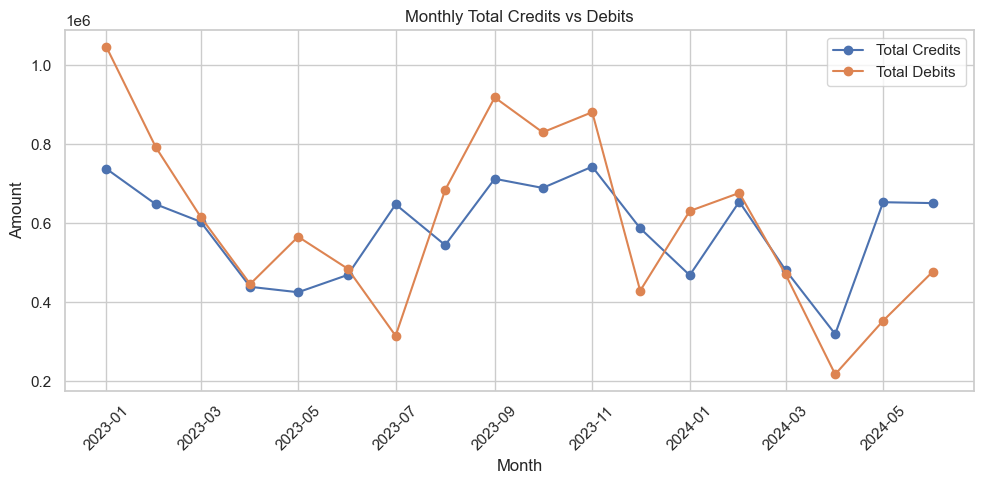

In [35]:
monthlysummary["Period"] = pd.to_datetime(
    monthlysummary["Year"].astype(str) + "-" +
    monthlysummary["Month"].astype(str).str.zfill(2) + "-01"
)

plt.figure(figsize=(10,5))
plt.plot(monthlysummary["Period"], monthlysummary["TotalCredits"], marker="o", label="Total Credits")
plt.plot(monthlysummary["Period"], monthlysummary["TotalDebits"], marker="o", label="Total Debits")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Monthly Total Credits vs Debits")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 ## Top and bottom net inflow accounts

C:\Users\Mohsin\AppData\Local\Temp\ipykernel_27824\1866368674.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Mohsin\AppData\Local\Temp\ipykernel_27824\1866368674.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


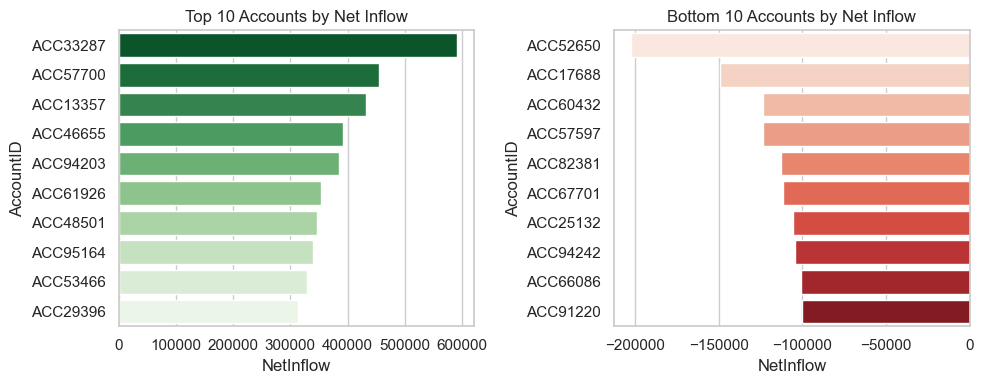

In [36]:
# Sort for top and bottom accounts
top_accounts = accountinflow.sort_values("NetInflow", ascending=False).head(10)
bottom_accounts = accountinflow.sort_values("NetInflow").head(10)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(
    data=top_accounts,
    x="NetInflow",
    y="AccountID",
    palette="Greens_r"
)
plt.title("Top 10 Accounts by Net Inflow")

plt.subplot(1,2,2)
sns.barplot(
    data=bottom_accounts,
    x="NetInflow",
    y="AccountID",
    palette="Reds"
)
plt.title("Bottom 10 Accounts by Net Inflow")
plt.tight_layout()
plt.show()


## Dormant vs active accounts

In [37]:
accountinflow.head()
accountinflow.columns




Index(['AccountID', 'NetInflow', 'TotalCredits', 'TotalDebits',
       'TransactionCount', 'AvgBalance', 'IsNetInflowAnomaly',
       'IsAvgBalanceAnomaly', 'IsAnyAnomaly'],
      dtype='object')

In [38]:
# Gap in months between consecutive transactions by account
df_sorted = df.sort_values(["AccountID", "TransactionDate"])
df_sorted["PrevDate"] = df_sorted.groupby("AccountID")["TransactionDate"].shift(1)
df_sorted["GapMonths"] = (
    (df_sorted["TransactionDate"] - df_sorted["PrevDate"]) / pd.Timedelta(days=30)
).round(0)

# Accounts with any gap >= 2 months
dormant_accounts = (
    df_sorted[df_sorted["GapMonths"] >= 2]
    .groupby("AccountID")
    .size()
    .reset_index(name="DormantGaps")
)

dormant_accounts["IsDormantAccount"] = 1
dormant_accounts.head()


,AccountID,DormantGaps,IsDormantAccount
0,ACC10117,2,1
1,ACC10996,2,1
2,ACC11062,1,1
3,ACC11188,4,1
4,ACC11285,2,1


In [39]:
# Merge dormant flag; fill missing as 0 (active)
accountinflow = accountinflow.merge(
    dormant_accounts[["AccountID", "IsDormantAccount"]],
    on="AccountID",
    how="left"
)

accountinflow["IsDormantAccount"] = accountinflow["IsDormantAccount"].fillna(0).astype(int)

accountinflow.columns


Index(['AccountID', 'NetInflow', 'TotalCredits', 'TotalDebits',
       'TransactionCount', 'AvgBalance', 'IsNetInflowAnomaly',
       'IsAvgBalanceAnomaly', 'IsAnyAnomaly', 'IsDormantAccount'],
      dtype='object')

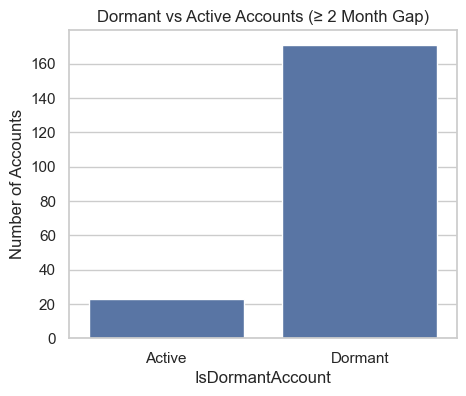

In [40]:
plt.figure(figsize=(5,4))
sns.countplot(x="IsDormantAccount", data=accountinflow)
plt.title("Dormant vs Active Accounts (≥ 2 Month Gap)")
plt.xticks([0,1], ["Active", "Dormant"])
plt.ylabel("Number of Accounts")
plt.show()


## Customer activity and balance segments

In [41]:
conditions = [
    accountinflow["TransactionCount"] <= 10,
    (accountinflow["TransactionCount"] > 10) & (accountinflow["TransactionCount"] <= 30),
    accountinflow["TransactionCount"] > 30
]

labels = ["Low Activity", "Medium Activity", "High Activity"]

accountinflow["ActivityLevel"] = np.select(
    conditions,
    labels,
    default="Low Activity"   # or "Unknown", but must be a string
)

accountinflow["ActivityLevel"].value_counts()





ActivityLevel
Low Activity       193
Medium Activity      1
Name: count, dtype: int64

In [42]:
accountinflow["ActivityLevel"].value_counts()


ActivityLevel
Low Activity       193
Medium Activity      1
Name: count, dtype: int64

In [43]:
# Calculate thresholds on TransactionCount
qlow = accountinflow["TransactionCount"].quantile(0.33)
qhigh = accountinflow["TransactionCount"].quantile(0.66)

def activitylevel(n):
    if n <= qlow:
        return "Low Activity"
    elif n <= qhigh:
        return "Medium Activity"
    else:
        return "High Activity"

accountinflow["ActivityLevel"] = accountinflow["TransactionCount"].apply(activitylevel)




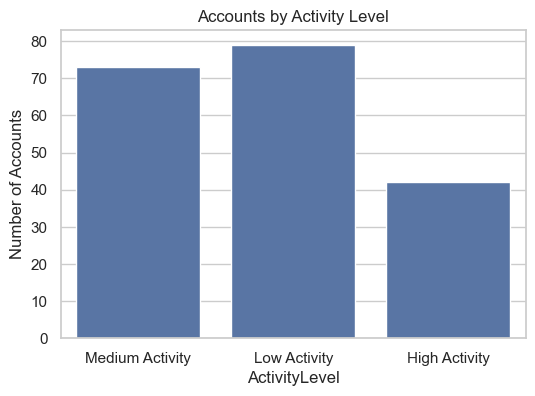

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x="ActivityLevel", data=accountinflow)
plt.title("Accounts by Activity Level")
plt.ylabel("Number of Accounts")
plt.show()


In [45]:
accountinflow["TransactionCount"].describe()
(accountinflow["TransactionCount"] > 10).sum(), (accountinflow["TransactionCount"] > 30).sum()


(np.int64(1), np.int64(0))

## Volume vs balance scatter (profile view)

In [46]:
accountinflow.columns



Index(['AccountID', 'NetInflow', 'TotalCredits', 'TotalDebits',
       'TransactionCount', 'AvgBalance', 'IsNetInflowAnomaly',
       'IsAvgBalanceAnomaly', 'IsAnyAnomaly', 'IsDormantAccount',
       'ActivityLevel'],
      dtype='object')

In [47]:
df["CreditAmount"] = np.where(df["TransactionType"] == "Credit Transaction",
                              df["TransactionAmount"], 0)
df["DebitAmount"] = np.where(df["TransactionType"] == "Debit Transaction",
                             df["TransactionAmount"], 0)

accountinflow = df.groupby("AccountID").agg(
    NetInflow=("SignedAmount", "sum"),
    TotalCredits=("CreditAmount", "sum"),
    TotalDebits=("DebitAmount", "sum"),
    TransactionCount=("TransactionID", "count"),
    AvgBalance=("AccountBalance", "mean")
).reset_index()


In [48]:
accountinflow.head()


,AccountID,NetInflow,TotalCredits,TotalDebits,TransactionCount,AvgBalance
0,ACC10117,199480.967430,142170.20378,0.00000,4,70107.007957
1,ACC10996,120819.856210,62580.86356,64959.84737,5,43568.008084
2,ACC11062,4014.264900,0.00000,0.00000,2,38137.132610
3,ACC11188,42532.553850,45748.34156,107522.02487,5,69652.151044
4,ACC11285,96729.609841,0.00000,0.00000,3,97401.348560


In [49]:
# Activity level from TransactionCount
qlow = accountinflow["TransactionCount"].quantile(0.33)
qhigh = accountinflow["TransactionCount"].quantile(0.66)

def activitylevel(n):
    if n <= qlow:
        return "Low Activity"
    elif n <= qhigh:
        return "Medium Activity"
    else:
        return "High Activity"

accountinflow["ActivityLevel"] = accountinflow["TransactionCount"].apply(activitylevel)

# Balance band from AvgBalance
blow = accountinflow["AvgBalance"].quantile(0.33)
bhigh = accountinflow["AvgBalance"].quantile(0.66)

def balanceband(b):
    if b <= blow:
        return "Low Balance"
    elif b <= bhigh:
        return "Medium Balance"
    else:
        return "High Balance"

accountinflow["BalanceBand"] = accountinflow["AvgBalance"].apply(balanceband)


In [50]:
print(accountinflow.columns)


Index(['AccountID', 'NetInflow', 'TotalCredits', 'TotalDebits',
       'TransactionCount', 'AvgBalance', 'ActivityLevel', 'BalanceBand'],
      dtype='object')


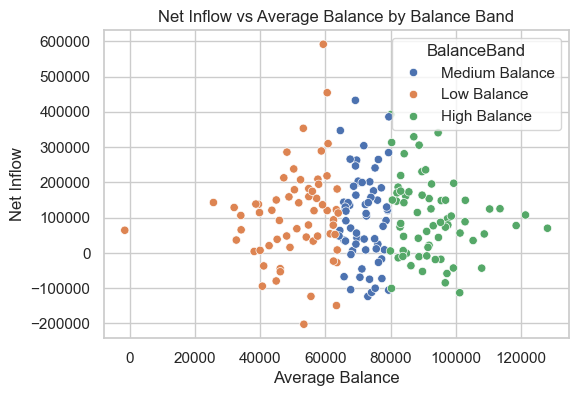

In [51]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=accountinflow,
    x="AvgBalance",
    y="NetInflow",
    hue="BalanceBand"
)
plt.title("Net Inflow vs Average Balance by Balance Band")
plt.xlabel("Average Balance")
plt.ylabel("Net Inflow")
plt.show()


## Volume vs balance scatter

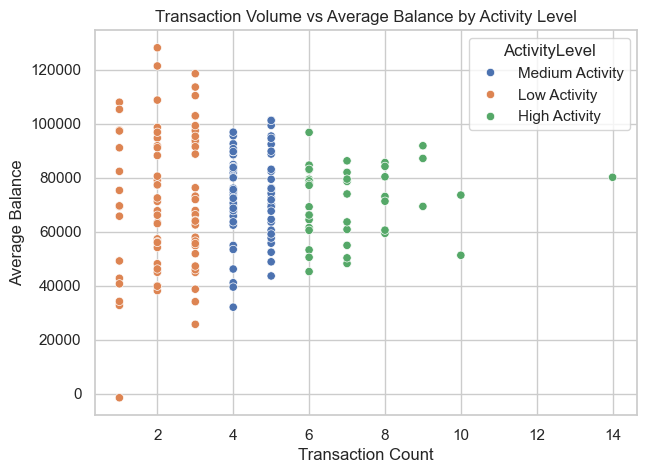

In [52]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=accountinflow,
    x="TransactionCount",
    y="AvgBalance",
    hue="ActivityLevel"
)
plt.title("Transaction Volume vs Average Balance by Activity Level")
plt.xlabel("Transaction Count")
plt.ylabel("Average Balance")
plt.show()


## Anomaly flag counts

In [53]:
# Step X: Anomaly detection using IQR (NetInflow and AvgBalance)

def iqr_flags(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

# 1) NetInflow anomalies
ni_lower, ni_upper = iqr_flags(accountinflow["NetInflow"])
accountinflow["IsNetInflowAnomaly"] = (
    (accountinflow["NetInflow"] < ni_lower) |
    (accountinflow["NetInflow"] > ni_upper)
).astype(int)

# 2) AvgBalance anomalies
ab_lower, ab_upper = iqr_flags(accountinflow["AvgBalance"])
accountinflow["IsAvgBalanceAnomaly"] = (
    (accountinflow["AvgBalance"] < ab_lower) |
    (accountinflow["AvgBalance"] > ab_upper)
).astype(int)

# 3) Combined anomaly flag: 1 if anomalous on either metric
accountinflow["IsAnyAnomaly"] = (
    (accountinflow["IsNetInflowAnomaly"] == 1) |
    (accountinflow["IsAvgBalanceAnomaly"] == 1)
).astype(int)

# Quick check: how many anomalies?
accountinflow["IsAnyAnomaly"].value_counts()



IsAnyAnomaly
0    187
1      7
Name: count, dtype: int64

In [54]:
print(accountinflow.columns)


Index(['AccountID', 'NetInflow', 'TotalCredits', 'TotalDebits',
       'TransactionCount', 'AvgBalance', 'ActivityLevel', 'BalanceBand',
       'IsNetInflowAnomaly', 'IsAvgBalanceAnomaly', 'IsAnyAnomaly'],
      dtype='object')


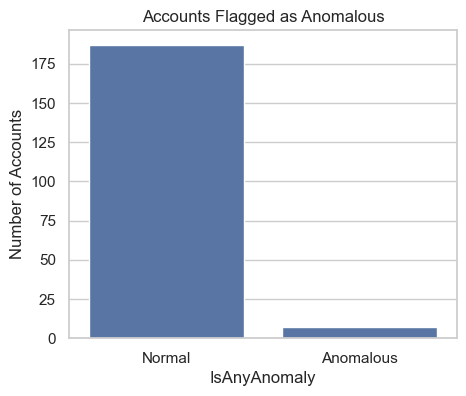

In [55]:
plt.figure(figsize=(5,4))
sns.countplot(x="IsAnyAnomaly", data=accountinflow)
plt.title("Accounts Flagged as Anomalous")
plt.xticks([0,1], ["Normal", "Anomalous"])
plt.ylabel("Number of Accounts")
plt.show()


## Risk flags – frequent large withdrawals and overdrafts

In [56]:
# === Task 4: Risk flags for large withdrawals and overdrafts ===

# 1. Flag large withdrawals (debit > 75,000)
df["IsLargeWithdrawal"] = np.where(
    (df["TransactionType"] == "Debit Transaction") & 
    (df["TransactionAmount"] > 75000),
    1, 0
)

# 2. Flag overdraft days (balance < 0)
df["IsOverdraft"] = np.where(df["AccountBalance"] < 0, 1, 0)

# 3. Aggregate to account level
riskflags = df.groupby("AccountID").agg(
    TotalTransactions=("TransactionID", "count"),
    LargeWithdrawals=("IsLargeWithdrawal", "sum"),
    OverdraftDays=("IsOverdraft", "sum")
).reset_index()

# 4. Calculate rates
riskflags["LargeWithdrawalRate"] = riskflags["LargeWithdrawals"] / riskflags["TotalTransactions"]
riskflags["OverdraftRate"] = riskflags["OverdraftDays"] / riskflags["TotalTransactions"]

# 5. Create binary flags (you can adjust thresholds)
freq_large_wd_min_rate = 0.20   # >= 20% of transactions
freq_overdraft_min_rate = 0.10  # >= 10% of transactions

riskflags["IsFreqLargeWithdrawal"] = (
    riskflags["LargeWithdrawalRate"] >= freq_large_wd_min_rate
).astype(int)

riskflags["IsFreqOverdraft"] = (
    riskflags["OverdraftRate"] >= freq_overdraft_min_rate
).astype(int)

# Quick check
riskflags.head()


,AccountID,TotalTransactions,LargeWithdrawals,OverdraftDays,LargeWithdrawalRate,OverdraftRate,IsFreqLargeWithdrawal,IsFreqOverdraft
0,ACC10117,4,0,0,0.0,0.0,0,0
1,ACC10996,5,0,0,0.0,0.0,0,0
2,ACC11062,2,0,0,0.0,0.0,0,0
3,ACC11188,5,0,0,0.0,0.0,0,0
4,ACC11285,3,0,0,0.0,0.0,0,0


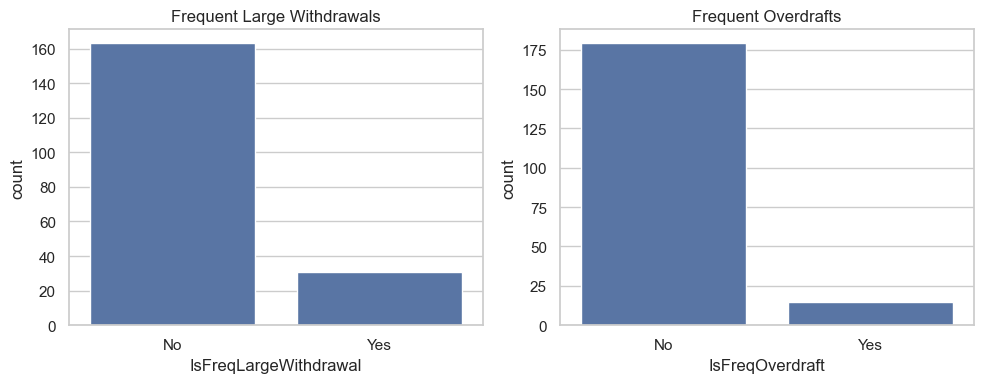

In [57]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x="IsFreqLargeWithdrawal", data=riskflags)
plt.title("Frequent Large Withdrawals")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(1,2,2)
sns.countplot(x="IsFreqOverdraft", data=riskflags)
plt.title("Frequent Overdrafts")
plt.xticks([0,1], ["No", "Yes"])

plt.tight_layout()
plt.show()


# Task 6: Hypothesis Testing

In [58]:
# Define high-volume (High Activity) vs low-volume (Low Activity)
high_volume = accountinflow[accountinflow["ActivityLevel"] == "High Activity"]["AvgBalance"]
low_volume = accountinflow[accountinflow["ActivityLevel"] == "Low Activity"]["AvgBalance"]

# Check sample sizes
print(f"High-volume accounts: {len(high_volume)}")
print(f"Low-volume accounts: {len(low_volume)}")


High-volume accounts: 42
Low-volume accounts: 79


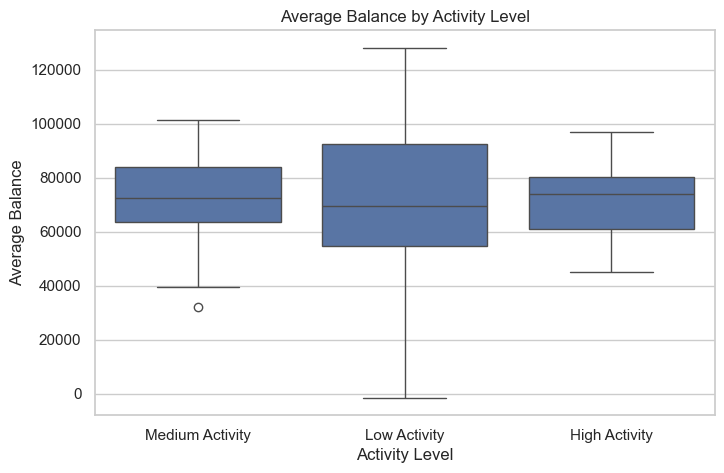

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=accountinflow, x="ActivityLevel", y="AvgBalance")
plt.title("Average Balance by Activity Level")
plt.ylabel("Average Balance")
plt.xlabel("Activity Level")
plt.show()


### Using an independent t-test to compare means:

In [60]:
from scipy import stats

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(high_volume, low_volume)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret results (α = 0.05)
if p_value < 0.05:
    print("\nResult: REJECT null hypothesis")
    print("High-volume accounts have significantly higher average balances than low-volume accounts.")
else:
    print("\nResult: FAIL TO REJECT null hypothesis")
    print("No significant difference in average balances between high and low-volume accounts.")


T-statistic: 0.0060
P-value: 0.9952

Result: FAIL TO REJECT null hypothesis
No significant difference in average balances between high and low-volume accounts.


### Calculate descriptive statistics

In [61]:
# Summary statistics for both groups
print("\nHigh-Volume Accounts:")
print(f"  Mean: {high_volume.mean():.2f}")
print(f"  Median: {high_volume.median():.2f}")
print(f"  Std Dev: {high_volume.std():.2f}")

print("\nLow-Volume Accounts:")
print(f"  Mean: {low_volume.mean():.2f}")
print(f"  Median: {low_volume.median():.2f}")
print(f"  Std Dev: {low_volume.std():.2f}")



High-Volume Accounts:
  Mean: 71412.03
  Median: 73728.68
  Std Dev: 12979.83

Low-Volume Accounts:
  Mean: 71386.95
  Median: 69343.48
  Std Dev: 25507.46
